# Aufgaben: Generatives Lernen

### Aufgabe 2: Implementierung (optional, ggf. längerfristig)

*Implementieren Sie ein GAN mit PyTorch. Verwenden Sie dafür einen beliebigen bildlichen Datensatz, bspw. MNIST.*


In [1]:
import random

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Sicherstellen, dass PyTorch die GPU verwenden kann, falls verfügbar
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Verwende Gerät: {device}")


# Um die Ergebnisse reproduzierbar zu machen:
# Es muss ein Seed gesetzt werden und deterministische Algorithmen verwendet werden
seed = 99
print("Random Seed: ", seed)
random.seed(seed)
torch.manual_seed(seed)
torch.use_deterministic_algorithms(True)  # Needed for reproducible results


Verwende Gerät: cpu
Random Seed:  99


#### Hyperparameter festlegen 

In [ ]:
# Zielgröße der Bilder, falls nicht alle schon einheitlich sind
image_size = 28

# Anzahl der Samples pro Batch
batch_size = 128

# Anzahl der Farbkanäle (1 für Graustufenbilder wie MNIST)
num_channels = 1

# Größe des latenten Vektors (Generator input)
z_dim = 100

# Größe der Feature Map im Generator
ngf = 64
# Größe der Feature Map im Diskriminator
ndf = 64

# Anzahl Trainingsepochen
num_epochs = 50

# Learning rate für Optimierer
lr_d = 0.0002
lr_g = 0.0002

# Beta Parameter für Adam-Optimierer
beta1 = 0.5
beta2 = 0.999

#### Transformieren des MNIST Datensatzes


Anzahl der Trainingsbilder: 60000
Größe eines transformierten Bildes: 28x28 Pixel mit 1 Kanal(en)


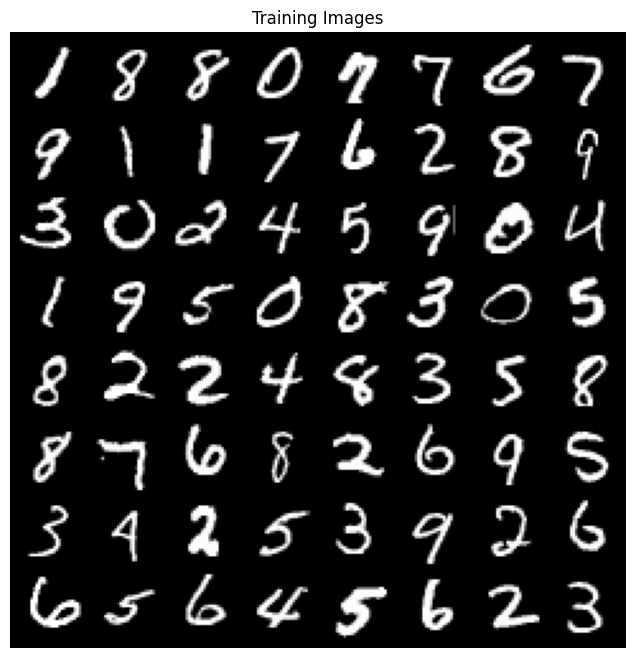

In [4]:
# Vorbereiten und einlesen der Daten
# Transformationen: Skalierung auf image_size, Umwandlung in Tensor, Normalisierung auf [-1, 1]
transform = transforms.Compose(
    [
        transforms.Resize(image_size),  # Bilder skalieren falls nicht einheitlich
        transforms.ToTensor(),  # Bilder in PyTorch Tensor umwandeln)
        transforms.Normalize(
            (0.5,), (0.5,)
        ),  # Normalisiert auf [-1, 1] (Mittelwert 0.5, Std.abw. 0.5 für einen Kanal)
    ]
)

# Laden des Trainings-Datensatzes
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transform, download=True
)

# DataLoader für das Training
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

print(f"Anzahl der Trainingsbilder: {len(train_dataset)}")
print(
    f"Größe eines transformierten Bildes: {image_size}x{image_size} Pixel mit {num_channels} Kanal(en)"
)

# Darstellung einiger Trainingsbilder
real_batch = next(iter(train_loader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(
            real_batch[0].to(device)[:64], padding=2, normalize=True
        ).cpu(),
        (1, 2, 0),
    )
)
plt.show()


### Generator definieren 

In [5]:
# erstelle ein einfaches Netz, das aus Rauschen Bilder erstellt
class Generator(nn.Module):
    def __init__(self, latent_dim, ngf, output_size, alpha_relu=0.2):
        super().__init__()
        # Schichten können direkt über Sequential in eine Art Pipeline gebracht werden
        self.layers = nn.Sequential(
            # Erstes Upsampling
            nn.Linear(
                latent_dim, 2 * ngf, bias=False
            ),  # Kein Bias, da BatchNormalization folgt
            nn.BatchNorm1d(2 * ngf),
            nn.LeakyReLU(alpha_relu),
            # Zweites Upsampling
            nn.Linear(2 * ngf, 4 * ngf, bias=False),
            nn.BatchNorm1d(4 * ngf),
            nn.LeakyReLU(alpha_relu),
            # Drittes Upsampling
            nn.Linear(4 * ngf, 8 * ngf, bias=False),
            nn.BatchNorm1d(8 * ngf),
            nn.LeakyReLU(alpha_relu),
            # Finales Upsampling
            nn.Linear(8 * ngf, output_size, bias=False),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.layers(x)

#### Diskriminator definieren

In [6]:
# Zweites Netz erstellen, dass die erstellten Bilder und echte Bilder bewertet
class Discriminator(nn.Module):
    def __init__(self, input_size, ndf, alpha_relu=0.2):
        super().__init__()
        self.layers = nn.Sequential(
            # Erste Schicht
            nn.Linear(input_size, 16 * ndf),
            nn.LeakyReLU(alpha_relu),
            # Zweite Schicht
            nn.Linear(16 * ndf, 8 * ndf),
            nn.LeakyReLU(alpha_relu),
            # Dritte Schicht
            nn.Linear(8 * ndf, 4 * ndf),
            nn.LeakyReLU(alpha_relu),
            # Letzte Schicht
            nn.Linear(4 * ndf, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

#### Instanzen der Netze erstellen

In [7]:
# Erstellen der Instanzen mit den Hyperparametern
output_size = image_size * image_size * num_channels

netG = Generator(latent_dim=z_dim, ngf=ngf, output_size=output_size).to(device)
netD = Discriminator(input_size=output_size, ndf=ndf).to(device)

# Zeigen der Netzarchitekturen
print(netG)
print(netD)

Generator(
  (layers): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=False)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=128, out_features=256, bias=False)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=256, out_features=512, bias=False)
    (7): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=512, out_features=784, bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=256, bias=True

### Verlustfunktion und Optimierer

In [8]:
# Verlustfunktion für das Training (Binary Cross-Entropy Loss)
criterion = nn.BCELoss()

# Labels für echtes (1) und gefälschtes (0) Training
real_label = 1.0
fake_label = 0.0

# Optimierer für G und D
optimizerD = optim.Adam(netD.parameters(), lr=lr_d, betas=(beta1, beta2))
optimizerG = optim.Adam(netG.parameters(), lr=lr_g, betas=(beta1, beta2))


### Training des GANs

In [ ]:
# Liste zur Speicherung von Trainingsstatistiken
img_list = []  # Zum Speichern von Beispielbildern, die vom Generator erstellt wurden
G_losses = []  # Generator-Verluste
D_losses = []  # Diskriminator-Verluste

# feste Rauschvektoren um den Fortschritt des GANs zu sehen
fixed_noise = torch.randn(
            batch_size, z_dim, device=device
        )

print("Starte GAN Training...")
for epoch in range(num_epochs):
    for i, data in enumerate(train_loader):
        # ------ Vorbereiten der Daten --------
        # Labeln der realen Bilder
        real_images = data[0].to(device)  # Echte Bilder
        real_batch_size = real_images.size(0)  # Wie viele Bilder wirklich im Batch sind
        label = torch.full(
            (real_batch_size, 1), real_label, dtype=torch.float, device=device
        )  # Labels für reale Bilder (1)
        real_images = real_images.view(real_images.size(0), -1) # Flatten der Bilder in 1D


        # ------ 1. Trainieren des Diskriminators --------
        # Trainieren des Diskriminators mit realen Bildern
        netD.zero_grad()
        real_images = real_images.view(real_images.size(0), -1)
        output = netD(real_images)  # Diskriminator-Ausgabe für reale Bilder
        errD_real = criterion(output, label)  # Verlust für reale Bilder
        errD_real.backward()  # Backward-Pass
        D_x = (
            output.mean().item()
        )  # Durchschnittliche Ausgabe des Diskriminators für reale Bilder

        # Trainiere mit "gefälschten" Bildern
        # Erstellen der Bilder
        noise = torch.randn(
            real_batch_size, z_dim, device=device
        )  # Zufallsrauschen für Generator
        fake = netG(noise)  # Generator erzeugt gefälschte Bilder
        label.fill_(fake_label)  # Labels für gefälschte Bilder (0)
        output = netD(
            fake.detach()
        )  # Diskriminator-Ausgabe für gefälschte Bilder (detach, damit G nicht aktualisiert wird)

        # Fehlerberechnung der gefälschten Bilder
        errD_fake = criterion(output, label)  # Verlust für gefälschte Bilder
        errD_fake.backward()  # Backward-Pass
        D_G_z1 = output.mean().item()  # Durchschnittliche Ausgabe des Diskriminators für gefälschte Bilder (bevor G trainiert wird)
        errD = errD_real + errD_fake  # Gesamtverlust des Diskriminators
        optimizerD.step()  # Diskriminator-Gewichte aktualisieren

        # ------ 2. Trainieren des Generators -------
        netG.zero_grad()  # Setze Gradienten des Generators zurück
        label.fill_(
            real_label
        )  # Labels sind jetzt 'real' (1), um G zu trainieren, D zu täuschen
        output = netD(
            fake
        )  # Diskriminator-Ausgabe für die neu generierten gefälschten Bilder
        errG = criterion(output, label)  # Verlust des Generators
        errG.backward()  # Backward-Pass
        D_G_z2 = output.mean().item()  # Durchschnittliche Ausgabe des Diskriminators für gefälschte Bilder (nach G-Training)
        optimizerG.step()  # Generator-Gewichte aktualisieren

        # --- 3. Fehler speichern und Fortschritt ausgeben ---
        if i % 200 == 0:  # Ausgabe alle 50 Batches
            print(
                f"[{epoch + 1}/{num_epochs}][{i}/{len(train_loader)}]\t"
                f"Loss_D: {errD.item():.4f}\tLoss_G: {errG.item():.4f}\t"
                f"D(x): {D_x:.4f}\tD(G(z))_before_G: {D_G_z1:.4f}\tD(G(z))_after_G: {D_G_z2:.4f}"
            )

        G_losses.append(errG.item())
        D_losses.append(errD.item())

    with torch.no_grad():
        fake_images_for_viz = netG(fixed_noise).detach().cpu()

        # Originale Dimensionen
        fake_images_for_viz = fake_images_for_viz.view(
            batch_size, num_channels, image_size, image_size
        )

        img_list.append(fake_images_for_viz)

print("GAN Training beendet.")


Starte GAN Training...
[1/50][0/469]	Loss_D: 1.4118	Loss_G: 0.6864	D(x): 0.4936	D(G(z))_before_G: 0.5062	D(G(z))_after_G: 0.5034
[1/50][200/469]	Loss_D: 1.4376	Loss_G: 0.5515	D(x): 0.4658	D(G(z))_before_G: 0.4744	D(G(z))_after_G: 0.5788
[1/50][400/469]	Loss_D: 0.9835	Loss_G: 1.4938	D(x): 0.8184	D(G(z))_before_G: 0.5352	D(G(z))_after_G: 0.2289
[2/50][0/469]	Loss_D: 1.0715	Loss_G: 0.4996	D(x): 0.4746	D(G(z))_before_G: 0.2284	D(G(z))_after_G: 0.6183
[2/50][200/469]	Loss_D: 0.8116	Loss_G: 1.1376	D(x): 0.6088	D(G(z))_before_G: 0.2313	D(G(z))_after_G: 0.3308
[2/50][400/469]	Loss_D: 0.8921	Loss_G: 0.8915	D(x): 0.5268	D(G(z))_before_G: 0.1672	D(G(z))_after_G: 0.4255
[3/50][0/469]	Loss_D: 1.0152	Loss_G: 0.2974	D(x): 0.4740	D(G(z))_before_G: 0.1449	D(G(z))_after_G: 0.7468
[3/50][200/469]	Loss_D: 0.8494	Loss_G: 0.7739	D(x): 0.5556	D(G(z))_before_G: 0.1444	D(G(z))_after_G: 0.4819
[3/50][400/469]	Loss_D: 0.6579	Loss_G: 1.5447	D(x): 0.7322	D(G(z))_before_G: 0.2508	D(G(z))_after_G: 0.2368
[4/50][0/46

### Visualisierung

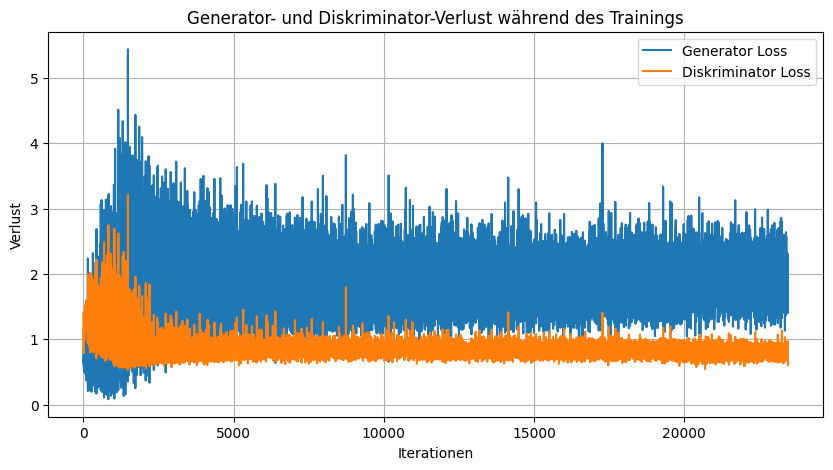

In [10]:
# Plot der Generator- und Diskriminator-Verluste
plt.figure(figsize=(10, 5))
plt.title("Generator- und Diskriminator-Verlust während des Trainings")
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Diskriminator Loss")
plt.xlabel("Iterationen")
plt.ylabel("Verlust")
plt.legend()
plt.grid(True)
plt.show()


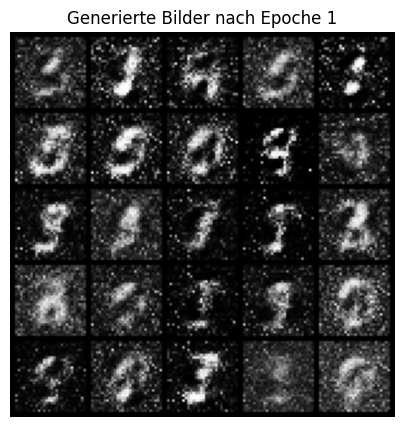

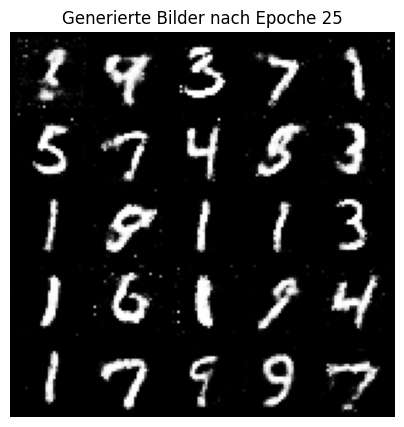

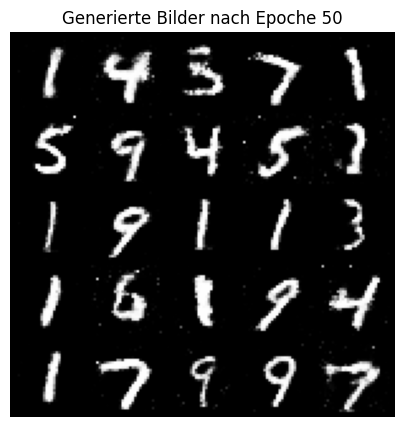

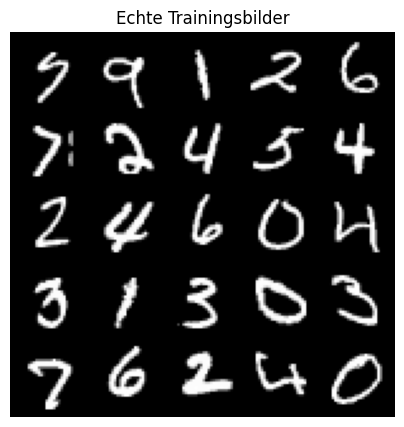

In [11]:
# Wie viele generierte Bilder dargestellt werden sollen
n_rows = 5
n_examples = n_rows*n_rows

# Visualisierung der generierten Bilder
# Zeige Bilder in verschiedenen Trainingsepochen
show_epochs = (1, int(num_epochs/2), num_epochs)
for epoch in show_epochs:
    fake_images = img_list[epoch-1]

    plt.figure(figsize=(n_rows, n_rows))
    plt.axis("off")
    plt.title(f"Generierte Bilder nach Epoche {epoch}")
    # make_grid normalisiert bereits, also imshow zeigt es richtig an
    plt.imshow(
        np.transpose(
            vutils.make_grid(
                fake_images[:n_examples], nrow=n_rows, padding=2, normalize=True
            ),
            (1, 2, 0),
        )
    )
    plt.show()


# Hole einen Batch echter Bilder vom DataLoader
real_batch = next(iter(train_loader))
plt.figure(figsize=(n_rows, n_rows))
plt.axis("off")
plt.title("Echte Trainingsbilder")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[0].to(device)[:n_examples], padding=2, nrow=n_rows, normalize=True).cpu(),
        (1, 2, 0),

    )
)
plt.show()
